# **Model Evaluation**

In [29]:
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve,auc,precision_score,recall_score,f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df=pd.read_csv('Titanic-Survival-Dataset/Data/processed/feature_engineered_data.csv')
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,FamilySize,IsAlone,Title,AgeBand
0,0,3,0,22.0,1,0,7.2500,False,True,2,0,0.0,2
1,1,1,1,38.0,1,0,71.2833,False,False,2,0,2.0,2
2,1,3,1,26.0,0,0,7.9250,False,True,1,1,1.0,2
3,1,1,1,35.0,1,0,53.1000,False,True,2,0,2.0,2
4,0,3,0,35.0,0,0,8.0500,False,True,1,1,0.0,2


In [3]:
lr=joblib.load('Titanic-Survival-Dataset/models/logistic_regression_model.pkl')
x_test,y_test=joblib.load('Titanic-Survival-Dataset/models/test_data.pkl')
lr_pred=lr.predict(x_test)
acc=accuracy_score(y_test,lr_pred)
precision=precision_score(y_test,lr_pred)
recall=recall_score(y_test,lr_pred)
f1=f1_score(y_test,lr_pred)
conf=confusion_matrix(y_test,lr_pred)


In [4]:
class_report_str=classification_report(y_test,lr_pred)
class_report_str

'              precision    recall  f1-score   support\n\n           0       0.81      0.89      0.85       105\n           1       0.81      0.70      0.75        74\n\n    accuracy                           0.81       179\n   macro avg       0.81      0.79      0.80       179\nweighted avg       0.81      0.81      0.81       179\n'

In [5]:
print(f'Accuracy: {acc:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')


Accuracy: 0.81
Precision: 0.81
Recall: 0.70
F1 Score: 0.75


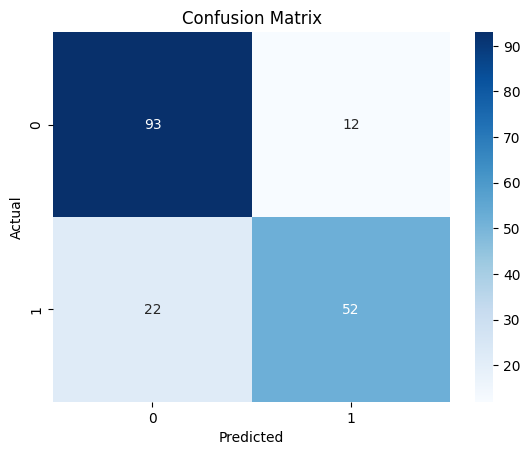

In [6]:
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [22]:
knn=joblib.load('Titanic-Survival-Dataset/models/knn_model.pkl')
knn_pred=knn.predict(x_test)
acc_knn=accuracy_score(y_test,knn_pred)
precision_knn=precision_score(y_test,knn_pred)
recall_knn=recall_score(y_test,knn_pred)
f1_knn=f1_score(y_test,knn_pred)
print(f'KNN Accuracy: {acc_knn:.2f}')
print(f'KNN Precision: {precision_knn:.2f}')    

print(f'KNN Recall: {recall_knn:.2f}')
print(f'KNN F1 Score: {f1_knn:.2f}')



KNN Accuracy: 0.80
KNN Precision: 0.79
KNN Recall: 0.70
KNN F1 Score: 0.74


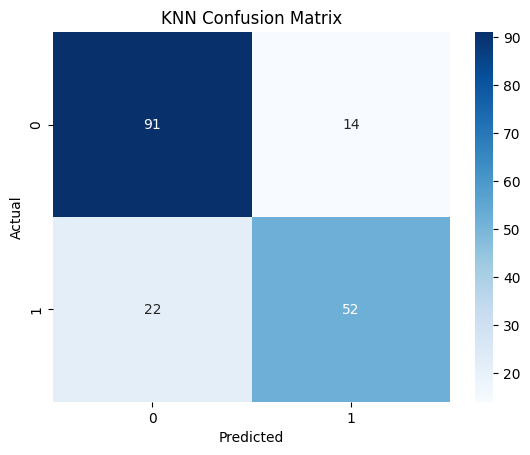

In [23]:
conf=confusion_matrix(y_test,knn_pred)
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Confusion Matrix')
plt.show()

Decision Tree Accuracy: 0.64
Decision Tree Precision: 0.57
Decision Tree Recall: 0.54
Decision Tree F1 Score: 0.56


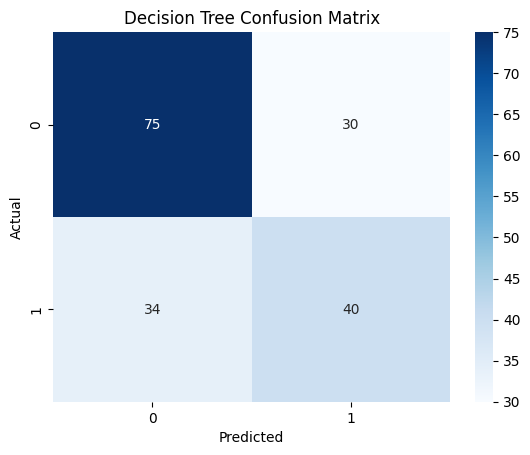

In [24]:
dt=joblib.load('Titanic-Survival-Dataset/models/decision_tree_model.pkl')
dt_pred=dt.predict(x_test)
acc_dt=accuracy_score(y_test,dt_pred)
precision_dt=precision_score(y_test,dt_pred)
recall_dt=recall_score(y_test,dt_pred)
f1_dt=f1_score(y_test,dt_pred)
print(f'Decision Tree Accuracy: {acc_dt:.2f}')
print(f'Decision Tree Precision: {precision_dt:.2f}')
print(f'Decision Tree Recall: {recall_dt:.2f}')
print(f'Decision Tree F1 Score: {f1_dt:.2f}')
conf=confusion_matrix(y_test,dt_pred)
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

Random Forest Accuracy: 0.74
Random Forest Precision: 0.68
Random Forest Recall: 0.69
Random Forest F1 Score: 0.68


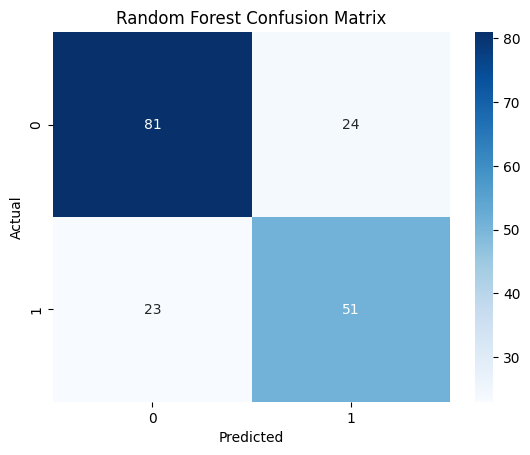

In [25]:
rf=joblib.load('Titanic-Survival-Dataset/models/random_forest_model.pkl')
rf_pred=rf.predict(x_test)
acc_rf=accuracy_score(y_test,rf_pred)
precision_rf=precision_score(y_test,rf_pred)
recall_rf=recall_score(y_test,rf_pred)
f1_rf=f1_score(y_test,rf_pred)
print(f'Random Forest Accuracy: {acc_rf:.2f}')
print(f'Random Forest Precision: {precision_rf:.2f}')
print(f'Random Forest Recall: {recall_rf:.2f}')
print(f'Random Forest F1 Score: {f1_rf:.2f}')
conf=confusion_matrix(y_test,rf_pred)
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()


In [30]:
lr_prob = lr.predict_proba(x_test)[:,1]
dt_prob = dt.predict_proba(x_test)[:,1]
rf_prob = rf.predict_proba(x_test)[:,1]
knn_prob = knn.predict_proba(x_test)[:,1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_prob)

lr_auc = auc(lr_fpr, lr_tpr)
dt_auc = auc(dt_fpr, dt_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
knn_auc = auc(knn_fpr, knn_tpr)

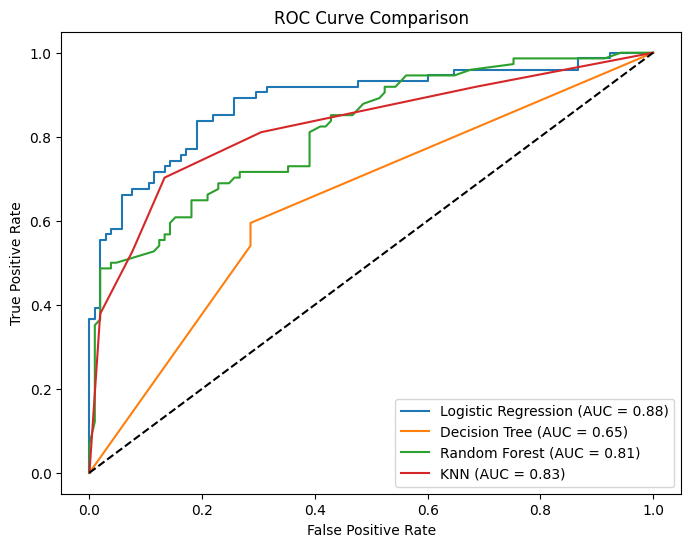

In [31]:
plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.2f})')
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC = {dt_auc:.2f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot(knn_fpr, knn_tpr, label=f'KNN (AUC = {knn_auc:.2f})')


plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

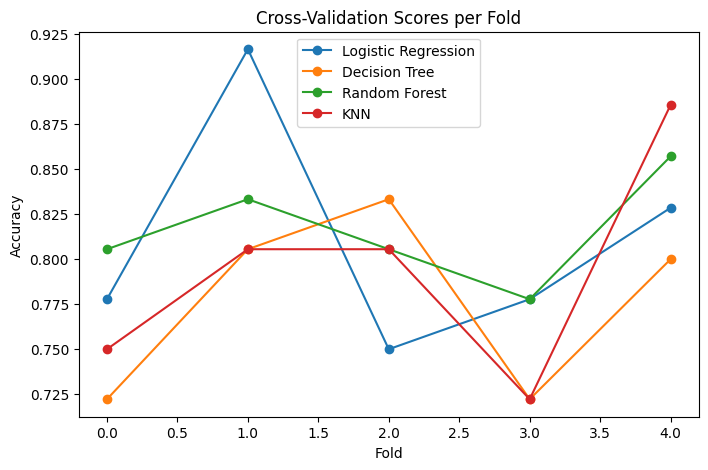

In [33]:
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "KNN": knn
}
cv_results = {}
cv_means = []
cv_std = []

for name, model in models.items():
    scores = cross_val_score(model, x_test, y_test, cv=5, scoring='accuracy')
    cv_results[name] = scores
    cv_means.append(scores.mean())
    cv_std.append(scores.std())

plt.figure(figsize=(8,5))

for name, scores in cv_results.items():
    plt.plot(scores, marker='o', label=name)

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Scores per Fold")
plt.legend()
plt.show()


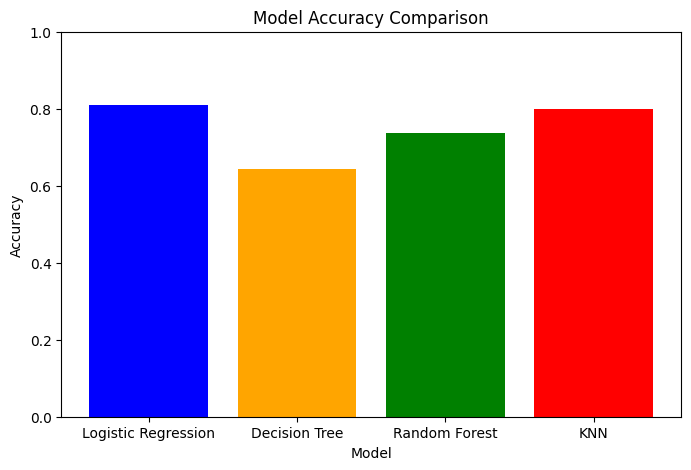

In [42]:
models=["Logistic Regression","Decision Tree","Random Forest","KNN"]
accuracy_scores = [acc, acc_dt, acc_rf, acc_knn]
plt.figure(figsize=(8,5))
plt.bar(models, accuracy_scores, color=['blue', 'orange', 'green', 'red'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.show()
